In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/dataset/DSB_Kenya_Cleaned_Dataset.xlsx'
df = pd.read_excel(path)
df.head(150)

,Period,Reporter,Partner,Comodity_Code,Unit,Quantity,Value
0,2017,Kenya,World,7108,kg,396375.00,13088382.43
1,2017,Kenya,"China, Hong Kong SAR",7108,kg,2.00,44734.06
2,2017,Kenya,Italy,7108,kg,1.00,9060.16
3,2017,Kenya,South Africa,7108,kg,281880.00,8831633.03
4,2017,Kenya,Eswatini,7108,kg,1.00,8213.23
...,...,...,...,...,...,...,...
139,2021,Kenya,"China, Hong Kong SAR",710813,kg,342.61,49153.70
140,2023,Kenya,World,710812,kg,65.11,7538086.68
141,2023,Kenya,China,710812,kg,6.05,225209.28
142,2020,Kenya,World,710813,kg,180.24,8613808.47


In [ ]:
df_filtered = df[df['Period'].isin([2017, 2018, 2019, 2020, 2021, 2022, 2023])]


In [ ]:
print(df_filtered.describe())


            Period  Comodity_Code       Quantity         Value
count   144.000000     144.000000     144.000000  1.440000e+02
mean   2020.006944  407828.520833   12193.559583  3.218904e+06
std       1.875482  349658.209246   58383.780814  6.598574e+06
min    2017.000000    7108.000000       0.040000  8.897000e+01
25%    2018.750000    7108.000000       1.000000  3.782803e+04
50%    2020.000000  710812.000000       5.525000  1.361131e+05
75%    2022.000000  710812.000000      89.907500  3.024843e+06
max    2023.000000  710813.000000  396375.000000  3.243741e+07


In [ ]:
partner_totals = df_filtered.groupby('Partner')['Value'].sum().reset_index()
print(partner_totals)

                        Partner         Value
0                      Cameroon  1.264310e+05
1                        Canada  7.565606e+04
2                         China  2.252093e+05
3          China, Hong Kong SAR  5.642779e+06
4                        Cyprus  1.008826e+05
5   Dem. People's Rep. of Korea  1.240864e+04
6        Dem. Rep. of the Congo  1.368613e+05
7                      Eswatini  1.642646e+04
8                      Ethiopia  7.133950e+04
9                        France  8.678580e+03
10                      Germany  1.065193e+05
11                        Italy  1.140427e+05
12                        Japan  2.588641e+05
13                      Nigeria  1.104720e+05
14                         Oman  4.316936e+04
15                     Paraguay  9.074600e+02
16                        Qatar  2.646331e+05
17                Rep. of Korea  1.371951e+06
18                     Slovenia  1.674026e+04
19                 South Africa  1.816094e+08
20                        Spain  3

In [ ]:
top_partners = partner_totals.nlargest(10, 'Value')
print(top_partners)

                 Partner         Value
26                 World  2.066805e+08
19          South Africa  1.816094e+08
21           Switzerland  4.056294e+07
24  United Arab Emirates  2.436944e+07
3   China, Hong Kong SAR  5.642779e+06
17         Rep. of Korea  1.371951e+06
25        United Kingdom  8.110141e+05
23                   USA  3.894394e+05
20                 Spain  3.492528e+05
16                 Qatar  2.646331e+05


<ipython-input-7-3bf7f0ded9f2>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_partners, x='Value', y='Partner', palette='viridis')


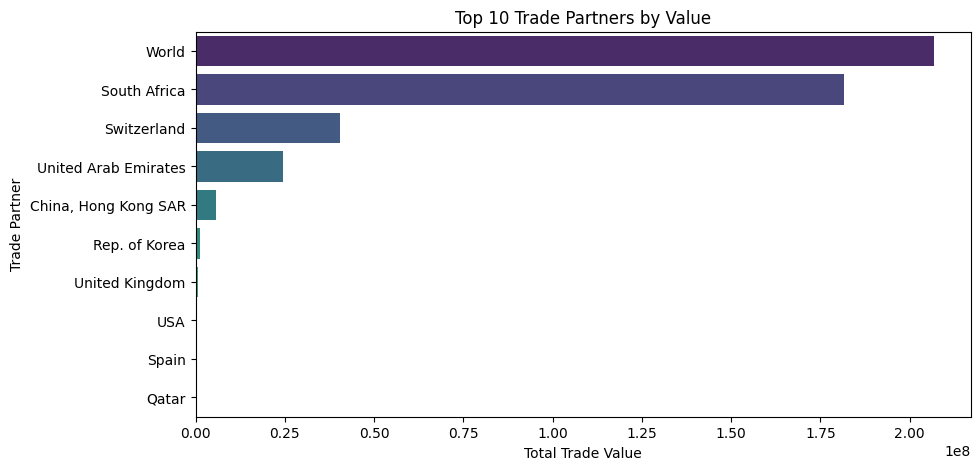

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 5))
sns.barplot(data=top_partners, x='Value', y='Partner', palette='viridis')
plt.xlabel("Total Trade Value")
plt.ylabel("Trade Partner")
plt.title("Top 10 Trade Partners by Value")
plt.show()